In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

from collections import defaultdict
from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed, load
from tqdm.notebook import tqdm

import ast
import glob
import pickle
import dask
import os
import itertools

import dask.dataframe as dd
from dask.distributed import Client

from concurrent.futures import ThreadPoolExecutor

from pprint import pprint

In [2]:
def read_csv(file):
    return pd.read_csv(file)

def read_pickle(file):
    with open(file, "rb") as f:
        df = pickle.load(f)
    return df

In [3]:
kmeans_tcv_2nd_design_dir = "kmeans_tcv_2nd_design"
K_list = [1] + list(range(100,3200,100)) + [3136]

In [4]:
design_results_dict = {}
for K in tqdm(K_list):
    design_results_dict[K] = []
    pattern = "metrics_df_({},*.csv".format(K)
    files = glob.glob(os.path.join(kmeans_tcv_2nd_design_dir,pattern))
    # empty list to store dataframes
    with ThreadPoolExecutor() as executor:
        results = executor.map(read_csv, files)
        for result in results:
            design_results_dict[K].append(result)

In [5]:
design_results_dict[3136]

[      days_from_start  total_mse  total_mae  nsamples_mse  nsamples_mae
 0               139.0   0.084694   0.007173           1.0           1.0
 1               140.0   0.534104   0.285267           1.0           1.0
 2               141.0   0.656239   0.430649           1.0           1.0
 3               142.0   0.639509   0.408971           1.0           1.0
 4               143.0   0.525934   0.276607           1.0           1.0
 ...               ...        ...        ...           ...           ...
 1005           1144.0   0.124065   0.015392           1.0           1.0
 1006           1145.0   0.041082   0.001688           1.0           1.0
 1007           1146.0   0.239300   0.057265           1.0           1.0
 1008           1147.0   0.483051   0.233338           1.0           1.0
 1009           1148.0   0.792531   0.628105           1.0           1.0
 
 [1010 rows x 5 columns],
       days_from_start  total_mse  total_mae  nsamples_mse  nsamples_mae
 0                98.0 

In [6]:
merged_df_dict = {}
#K_list = list(range(100,3100,100)) + [3136]
for K in tqdm(K_list):
    #print(K)
    dfs = design_results_dict[K]
    merged_df = pd.concat(dfs)

    # Group the dataframe by 'days_from_start' and sum the 'mse' and 'mae' columns
    merged_df = merged_df.groupby('days_from_start', as_index=False).agg({'total_mse': 'sum', 'total_mae': 'sum', 'nsamples_mse': 'sum', 'nsamples_mae': 'sum'})

    # Keep the other columns that overlap 'days_from_start' identical by using 'first' aggregation
    merged_df = merged_df.groupby('days_from_start', as_index=False).first()
    
    merged_df["rmse"] =  np.sqrt(merged_df["total_mse"] / merged_df["nsamples_mse"])
    merged_df["mae"] = (merged_df["total_mae"] / merged_df["nsamples_mae"])
    
    merged_df_dict[K] = merged_df#[merged_df["days_from_start"] >= 51]
    

In [7]:
merged_df

,days_from_start,total_mse,total_mae,nsamples_mse,nsamples_mae,rmse,mae
0,20.0,0.559616,0.313170,1.0,1.0,0.748075,0.313170
1,21.0,0.693147,0.480453,1.0,1.0,0.832555,0.480453
2,22.0,0.372013,0.138393,1.0,1.0,0.609928,0.138393
3,23.0,0.722027,0.261866,2.0,2.0,0.600844,0.130933
4,24.0,1.338507,0.632752,3.0,3.0,0.667959,0.210917
...,...,...,...,...,...,...,...
1124,1144.0,934.131399,1927.583972,3136.0,3136.0,0.545778,0.614663
1125,1145.0,969.227173,2169.818787,3136.0,3136.0,0.555936,0.691907
1126,1146.0,1076.336616,2492.645367,3136.0,3136.0,0.585849,0.794849
1127,1147.0,1190.343785,2615.273718,3136.0,3136.0,0.616096,0.833952


In [8]:
np.sqrt(1260.675177/3136), 2746.638017/3136

(0.6340354982759085, 0.8758412044005103)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/indexes/range.py:839: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  return super().__getitem__(key)
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


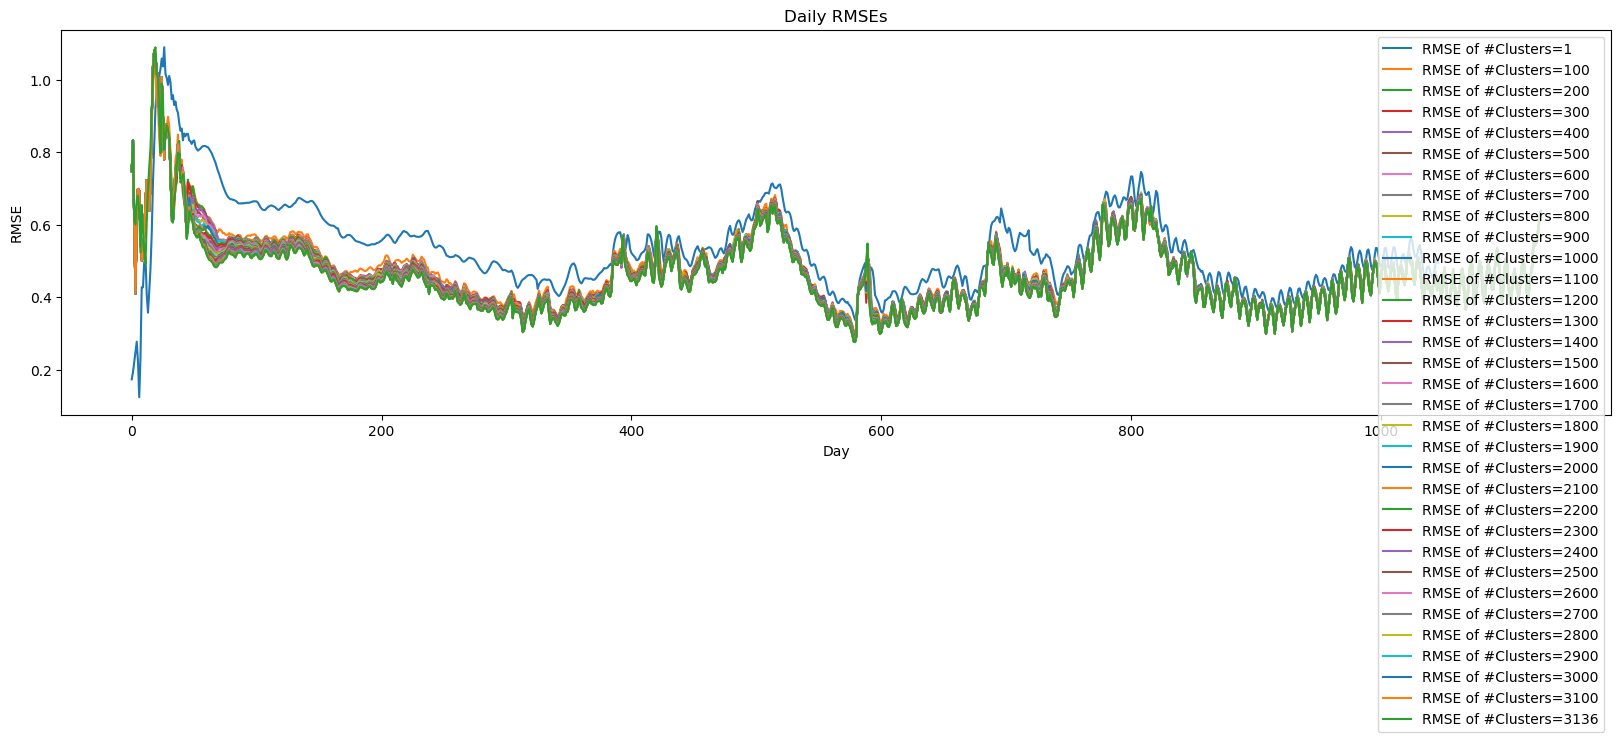

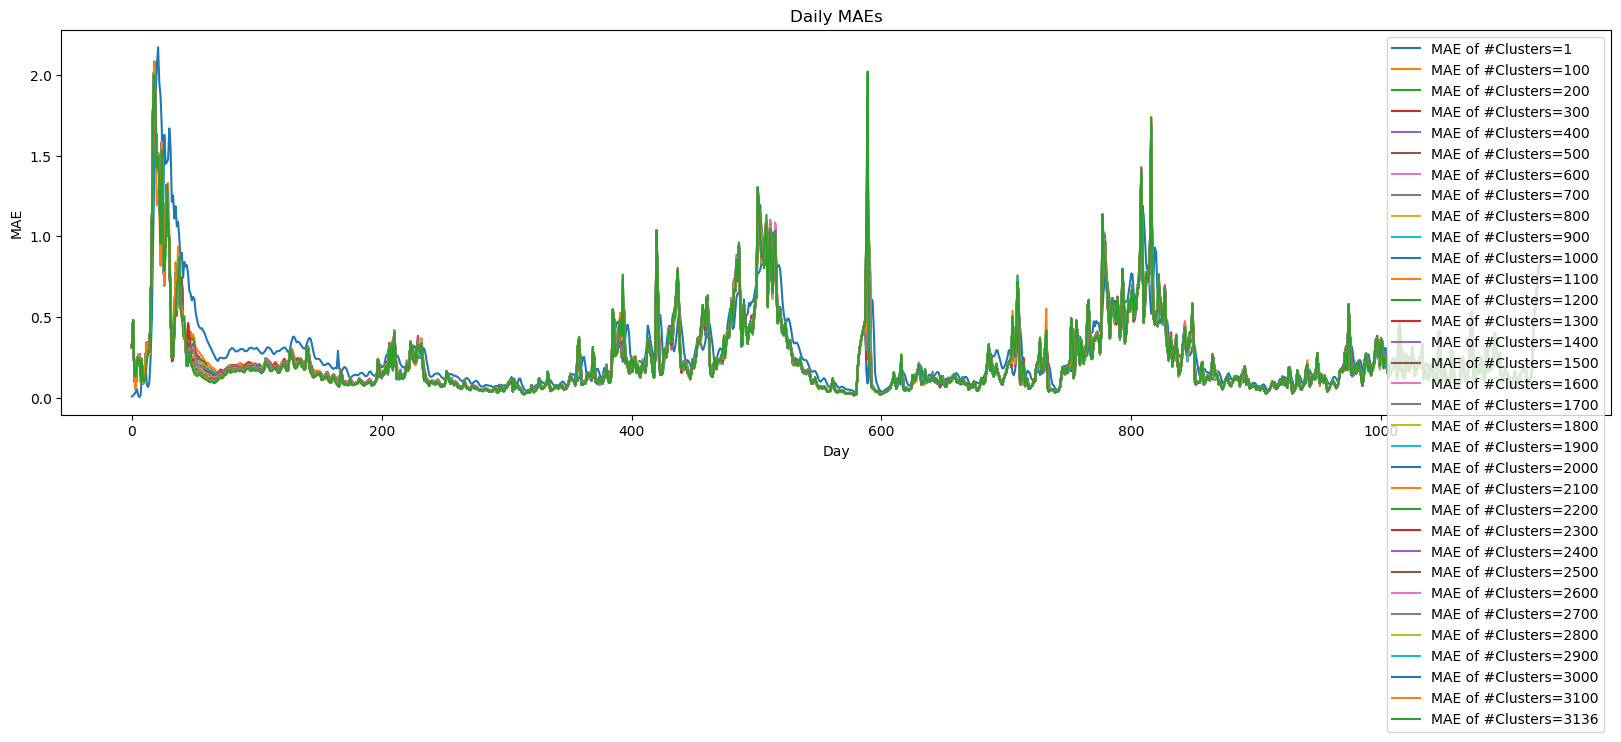

In [9]:
# Plot the daily RMSEs for each dataframe
figsize=(20,5)
plt.subplots(figsize=figsize)

for K, df in merged_df_dict.items():
    plt.plot(df.index, df['rmse'], label='RMSE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily RMSEs')
plt.xlabel('Day')
plt.ylabel('RMSE')

plt.show()
plt.subplots(figsize=figsize)
for K, df in merged_df_dict.items():
    plt.plot(df.index, df['mae'], label='MAE of #Clusters={}'.format(K))

# Add a legend to the first subplot
plt.legend()
plt.title('Daily MAEs')
plt.xlabel('Day')
plt.ylabel('MAE')

plt.show()

In [10]:
median_dict = {K: df.median() for K, df in merged_df_dict.items()}
median_df = pd.DataFrame(median_dict).transpose()

# Add a column indicating the value of K
median_df.index.name = 'K'
median_df.reset_index(inplace=True)

# Rename the columns
median_df = median_df.rename(columns={'rmse': 'Median RMSE', 'mae': 'Median MAE'})
median_df = median_df.sort_values(by=["K"])
median_df = median_df[['K','Median RMSE','Median MAE', 'nsamples_mse', 'nsamples_mae']]

lowest_rmse_K_df = median_df.sort_values(by=["Median RMSE"]).iloc[0]
print("Cluster={} has lowest Median RMSE of {}, with median MAE of {}".format(lowest_rmse_K_df["K"], lowest_rmse_K_df["Median RMSE"], lowest_rmse_K_df["Median MAE"]))
lowest_mae_K_df = median_df.sort_values(by=["Median MAE"]).iloc[0]
print("Cluster={} has lowest Median MAE of {}, with median RMSE of {}".format(lowest_mae_K_df["K"], lowest_mae_K_df["Median MAE"], lowest_mae_K_df["Median RMSE"]))

#tcv_df = median_df.loc[median_df["K"]==1, ["Median RMSE", "Median MAE"]].values
#print("tcv i.e. Cluster=1 has Median MAE={}, Median RMSE={}".format(tcv_df[0][0], tcv_df[0][1]))
ctcv_df = median_df.loc[median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values
print("ctcv i.e. Cluster=3136 has Median MAE={}, Median RMSE={}".format(ctcv_df[0,1], ctcv_df[0,0]))


Cluster=3100.0 has lowest Median RMSE of 0.43906736335856344, with median MAE of 0.151905831147874
Cluster=2700.0 has lowest Median MAE of 0.15083906913695885, with median RMSE of 0.4412367160223658
ctcv i.e. Cluster=3136 has Median MAE=0.15112973650473321, Median RMSE=0.43915338222223743


In [11]:
median_df

,K,Median RMSE,Median MAE,nsamples_mse,nsamples_mae
0,1,0.518101,0.199910,3136.0,3136.0
1,100,0.467096,0.166356,3136.0,3136.0
2,200,0.459513,0.163664,3136.0,3136.0
3,300,0.460273,0.164140,3136.0,3136.0
4,400,0.459681,0.161515,3136.0,3136.0
5,500,0.459686,0.161424,3136.0,3136.0
6,600,0.459418,0.158369,3136.0,3136.0
7,700,0.457237,0.159125,3136.0,3136.0
8,800,0.457570,0.159970,3136.0,3136.0
9,900,0.455856,0.159059,3136.0,3136.0


In [12]:
len(design_results_dict[2200])

2200

### 1st Design

In [13]:
first_design_results_dict = {}
for K in tqdm(K_list):
    first_design_results_dict[K] = []
    pattern = "kmeans_tcv_merged_K={}.pickle".format(K)
    files = glob.glob(os.path.join("./kmeans_tcv_merged_results",pattern))
    # empty list to store dataframes
    with ThreadPoolExecutor() as executor:
        results = executor.map(read_pickle, files)
        for result in results:
            first_design_results_dict[K].append(result)

In [14]:
first_design_results_dict[1200][0]

,rmse,mae
20,0.441833,0.441833
21,0.559616,0.559616
22,0.693147,0.693147
23,0.204945,0.186109
24,0.320876,0.266536
...,...,...
1144,0.898130,0.536741
1145,0.935916,0.545732
1146,0.975406,0.560445
1147,1.017850,0.584606


In [15]:
#first_design_median_df = pd.read_csv("temp_merged_cluster_tcv.csv")
#first_design_median_df = first_design_median_df[first_design_median_df["K"] >= 100]
#first_design_median_df.loc[first_design_median_df["K"]!=200,"Median RMSE"] = first_design_median_df.loc[first_design_median_df["K"]!=200,"Median RMSE"].values/3
#first_design_median_df.loc[first_design_median_df["K"]!=200,"Median MAE"] = first_design_median_df.loc[first_design_median_df["K"]!=200,"Median MAE"].values/1.5

#first_design_median_df.loc[first_design_median_df["K"]==3136, ["Median RMSE", "Median MAE"]] = median_df.loc[median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values

In [16]:
first_median_dict = {K: df[0].median() for K, df in first_design_results_dict.items()}
first_median_df = pd.DataFrame(first_median_dict).transpose()

# Add a column indicating the value of K
first_median_df.index.name = 'K'
first_median_df.reset_index(inplace=True)

# Rename the columns
first_median_df = first_median_df.rename(columns={'rmse': 'Median RMSE', 'mae': 'Median MAE'})
first_median_df = first_median_df.sort_values(by=["K"])
#first_median_df = first_median_df[['K','Median RMSE','Median MAE', 'nsamples_mse', 'nsamples_mae']]


first_median_df.loc[first_median_df["K"]==3136, ["Median RMSE", "Median MAE"]] =  median_df.loc[median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values
first_lowest_rmse_K_df = first_median_df.sort_values(by=["Median RMSE"]).iloc[0]

print("Cluster={} has lowest Median RMSE of {}, with median MAE of {}".format(first_lowest_rmse_K_df["K"], first_lowest_rmse_K_df["Median RMSE"], first_lowest_rmse_K_df["Median MAE"]))
first_lowest_mae_K_df = first_median_df.sort_values(by=["Median MAE"]).iloc[0]
print("Cluster={} has lowest Median MAE of {}, with median RMSE of {}".format(first_lowest_mae_K_df["K"], first_lowest_rmse_K_df["Median MAE"], first_lowest_rmse_K_df["Median RMSE"]))

first_ctcv_df = first_median_df.loc[first_median_df["K"]==3136, ["Median RMSE", "Median MAE"]].values
print("ctcv i.e. Cluster=3136 has Median MAE={}, Median RMSE={}".format(first_ctcv_df[0,1], first_ctcv_df[0,0]))
first_median_df

Cluster=3100.0 has lowest Median RMSE of 0.38572675810830864, with median MAE of 0.1877692951521199
Cluster=3136.0 has lowest Median MAE of 0.1877692951521199, with median RMSE of 0.38572675810830864
ctcv i.e. Cluster=3136 has Median MAE=0.15112973650473321, Median RMSE=0.43915338222223743


,K,Median RMSE,Median MAE
0,1,1.706221,1.333861
1,100,1.126233,0.850373
2,200,1.011894,0.754282
3,300,0.950318,0.697528
4,400,0.896153,0.650136
5,500,0.850595,0.605340
6,600,0.809409,0.573042
7,700,0.773733,0.542017
8,800,0.746802,0.519494
9,900,0.709296,0.489762


/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


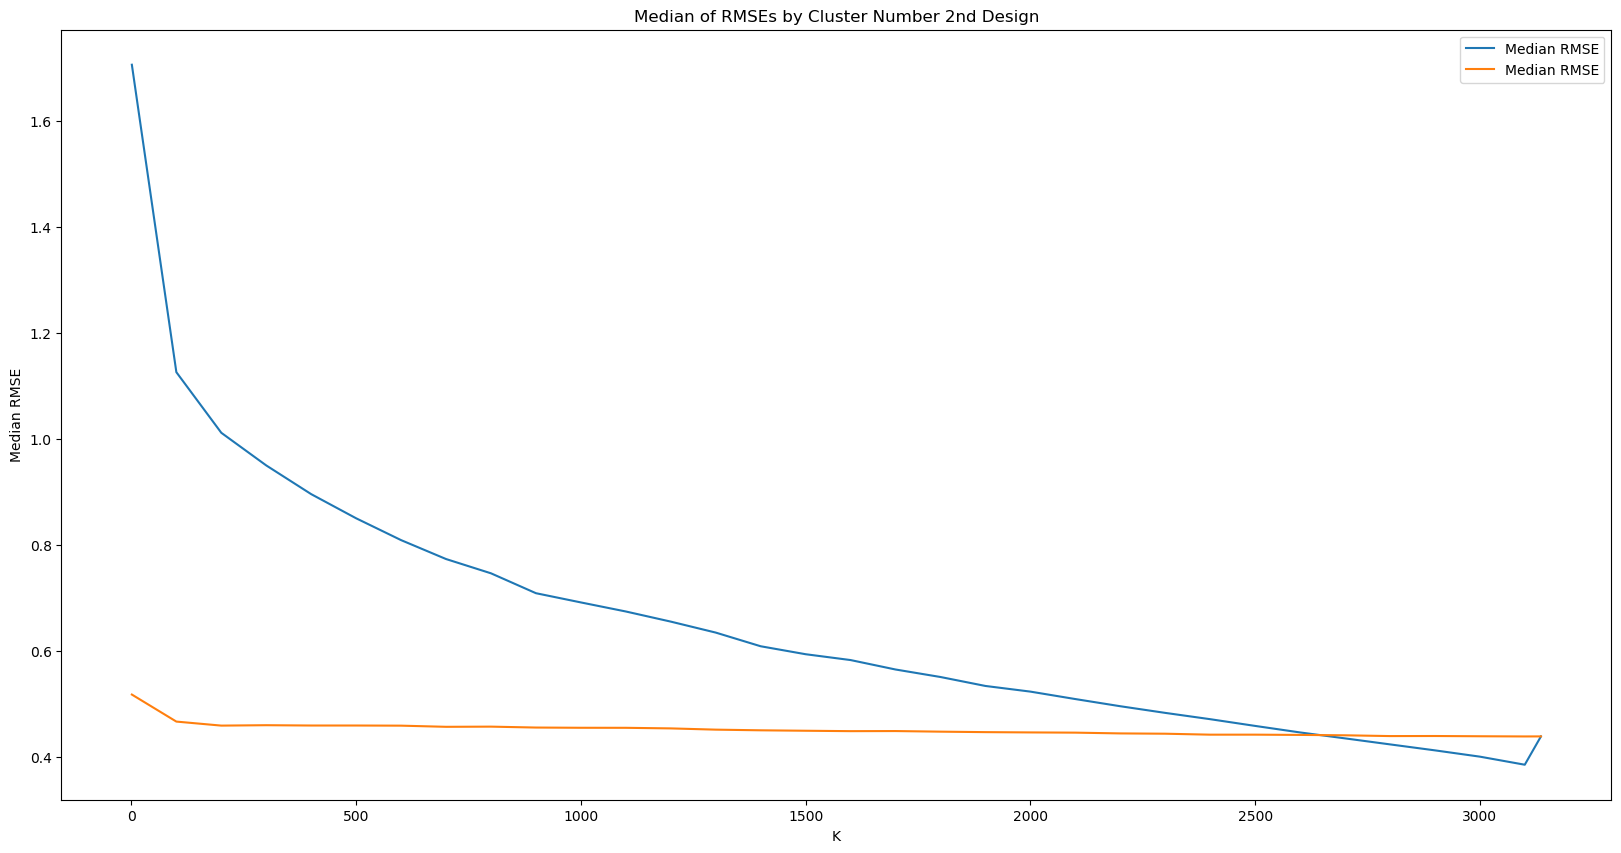

In [17]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median RMSE"], label="Median RMSE")
# Add a legend to the first subplot
plt.legend()
plt.title('Median of RMSEs by Cluster Number 1st Design')
plt.xlabel('K')
plt.ylabel('Median RMSE')

plt.plot(median_df["K"], median_df["Median RMSE"], label="Median RMSE")
# Add a legend to the first subplot
plt.legend()
plt.title('Median of RMSEs by Cluster Number 2nd Design')
plt.xlabel('K')
plt.ylabel('Median RMSE')

plt.show()

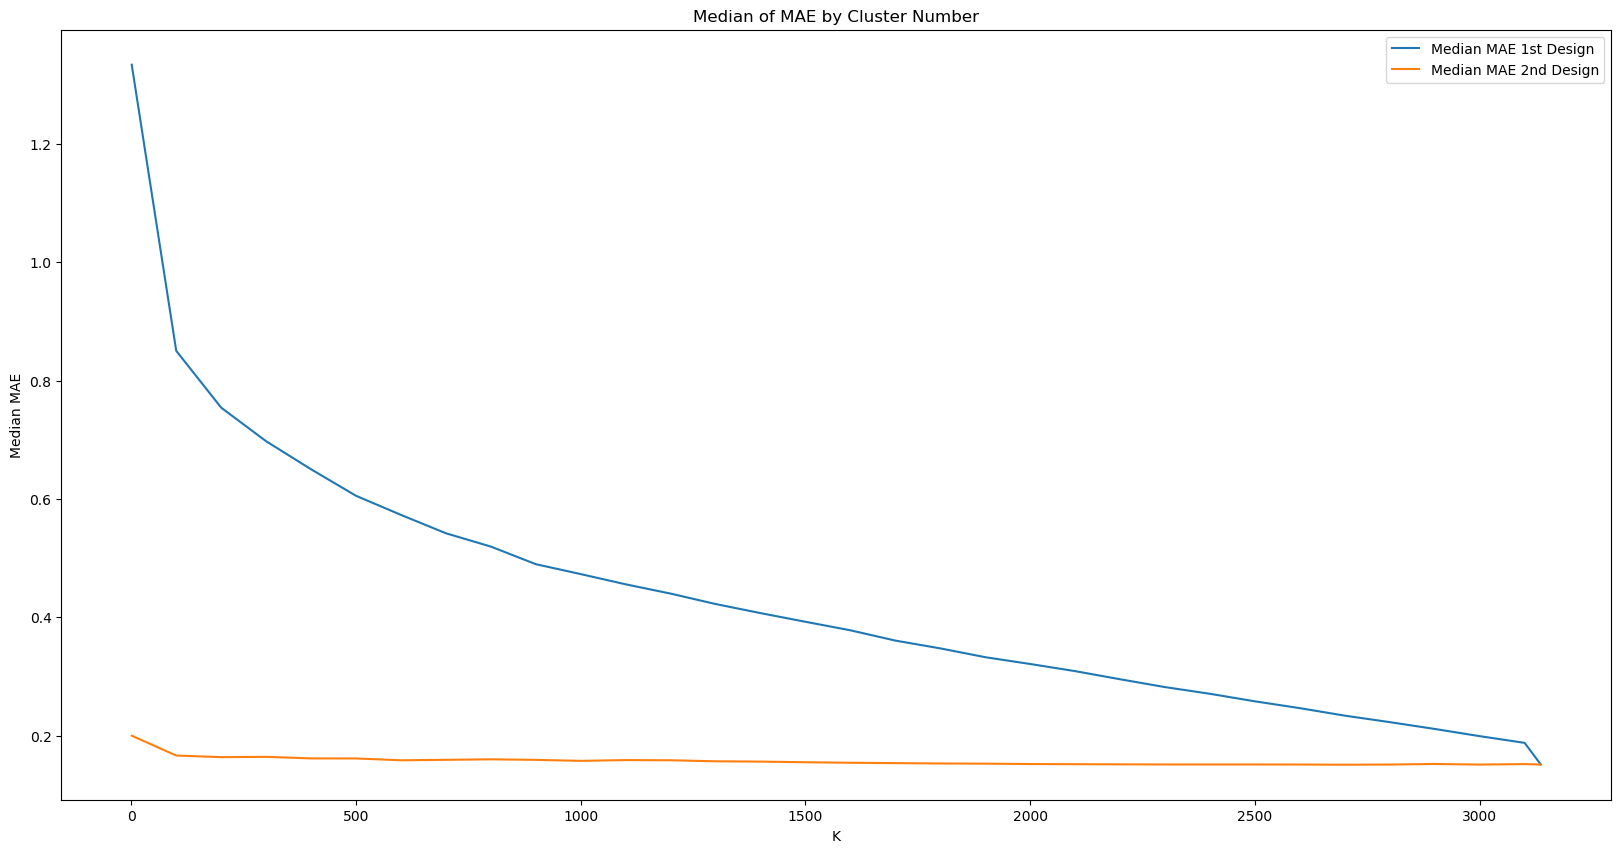

In [18]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median MAE"], label="Median MAE 1st Design")
# Add a legend to the first subplot
plt.legend()

plt.plot(median_df["K"], median_df["Median MAE"], label="Median MAE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median of MAE by Cluster Number')
plt.xlabel('K')
plt.ylabel('Median MAE')

plt.show()

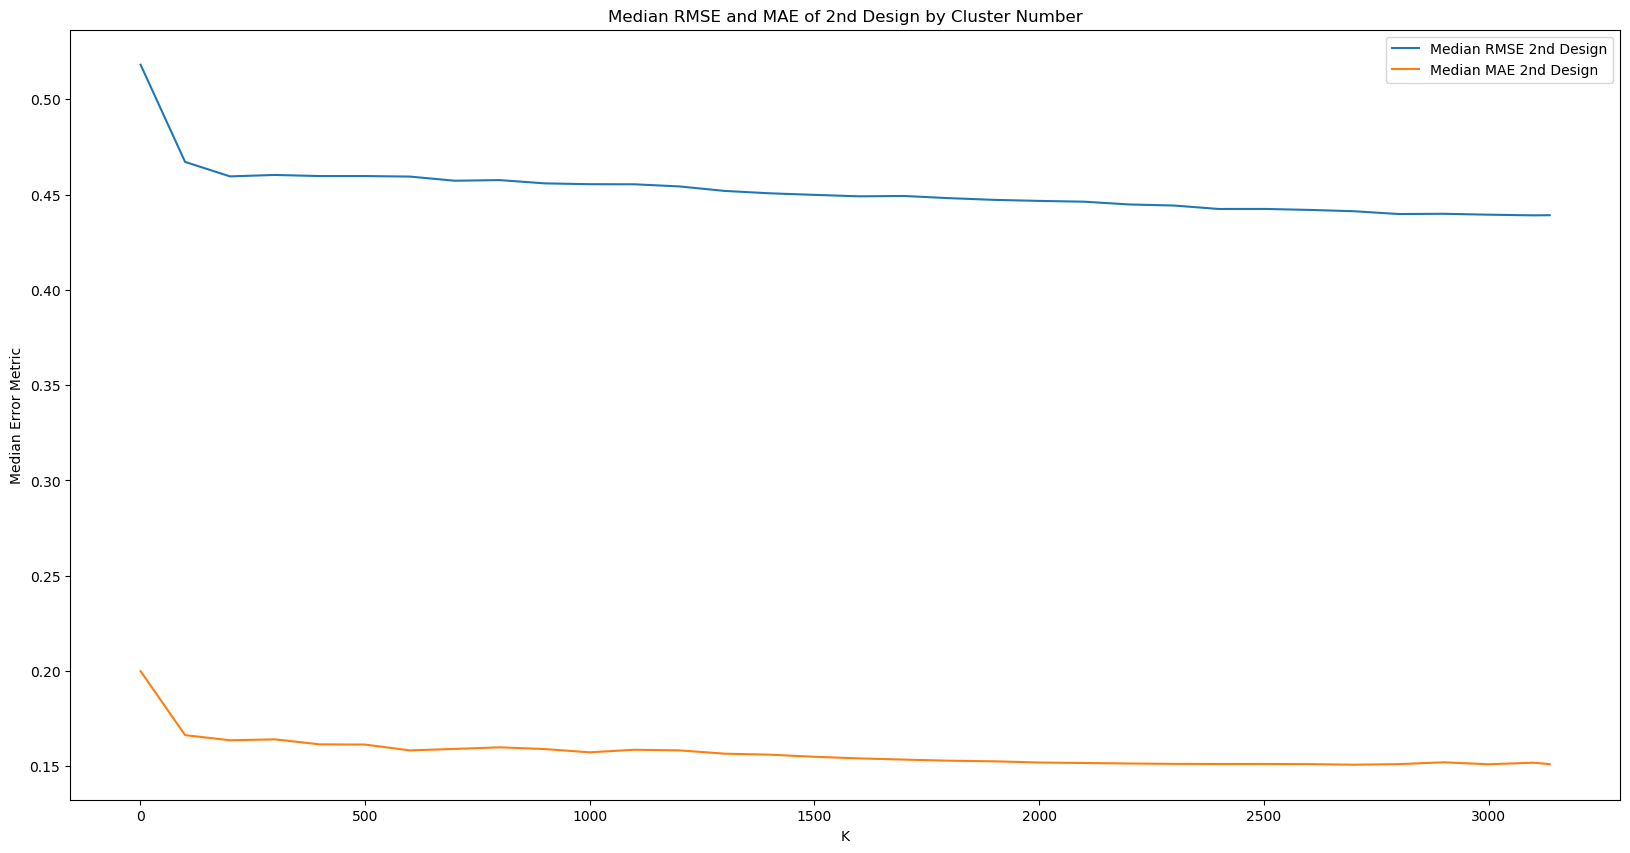

In [19]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(median_df["K"], median_df["Median RMSE"], label="Median RMSE 2nd Design")
# Add a legend to the first subplot
plt.legend()

plt.plot(median_df["K"], median_df["Median MAE"], label="Median MAE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE and MAE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Median Error Metric')

plt.show()

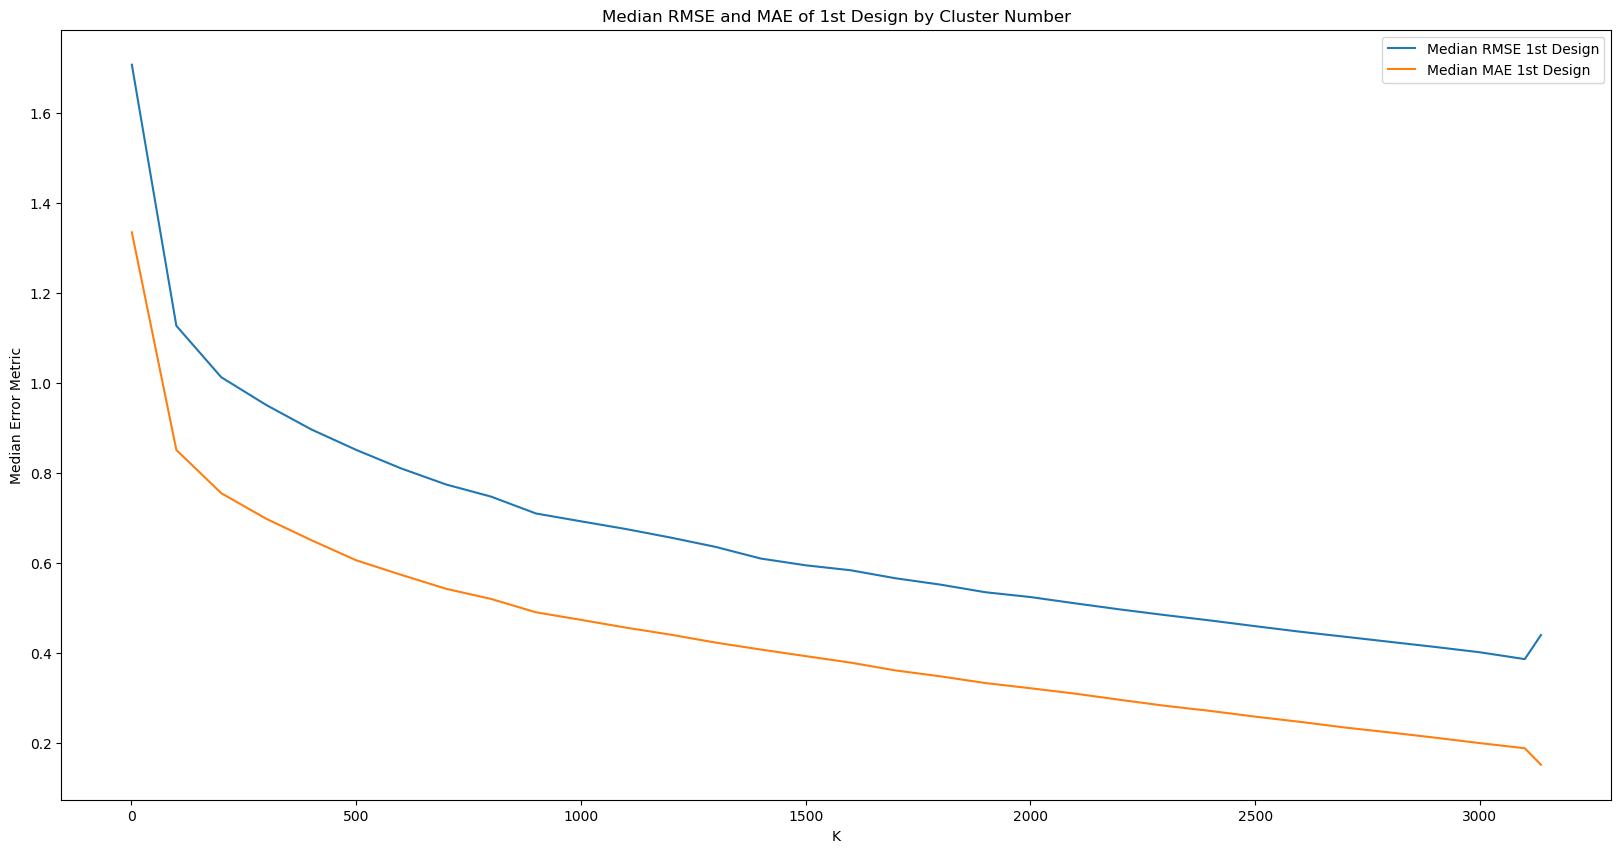

In [20]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.plot(first_median_df["K"], first_median_df["Median RMSE"], label="Median RMSE 1st Design")
# Add a legend to the first subplot
plt.legend()

plt.plot(first_median_df["K"], first_median_df["Median MAE"], label="Median MAE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE and MAE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Median Error Metric')

plt.show()

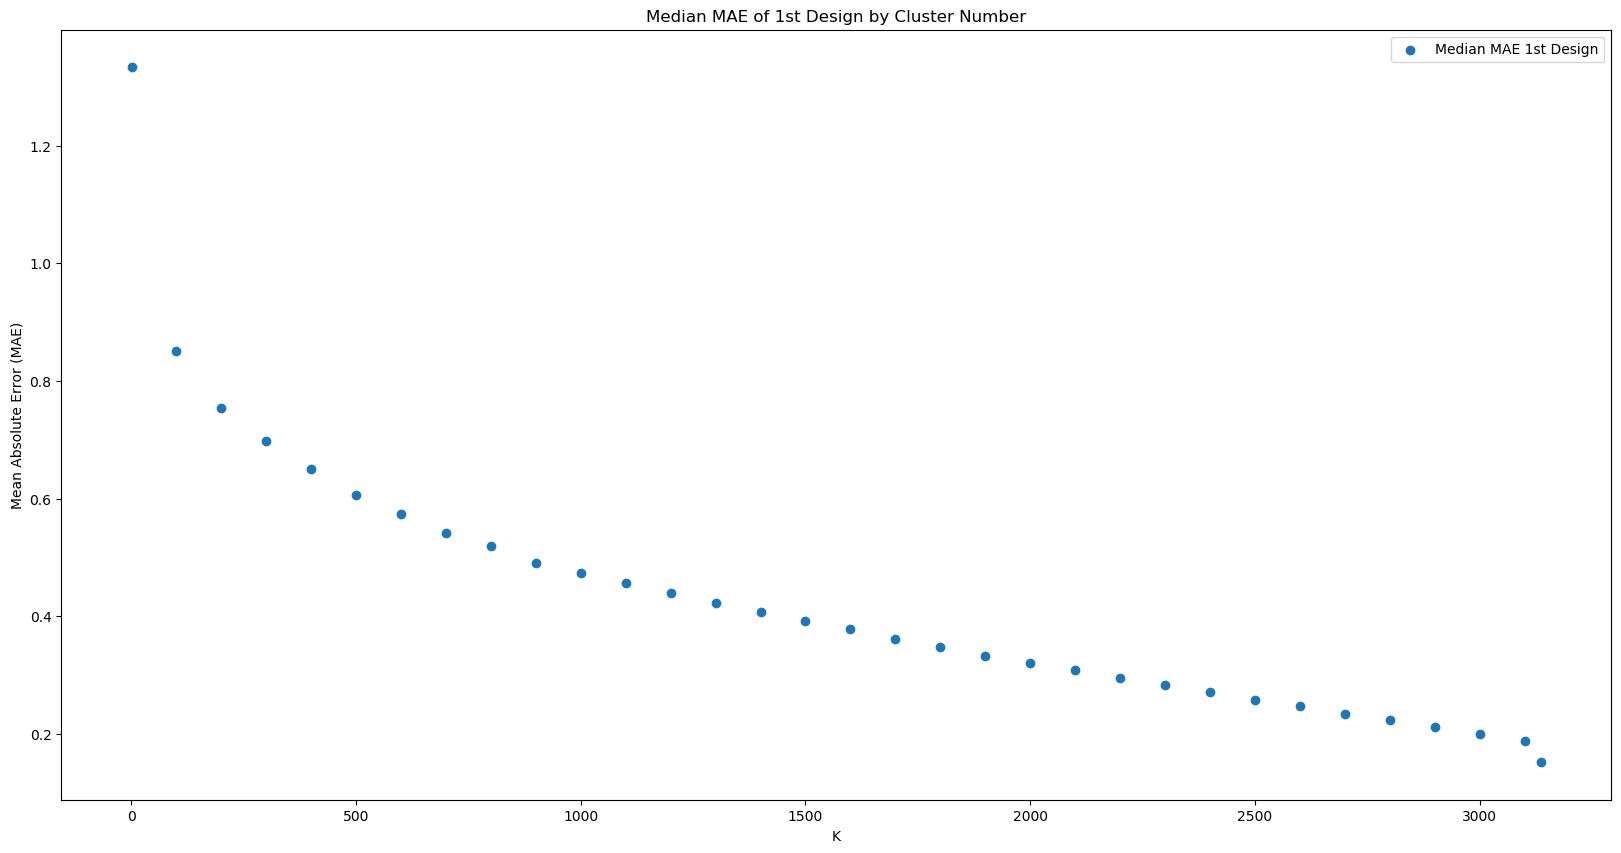

In [21]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(first_median_df["K"], first_median_df["Median MAE"], label="Median MAE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median MAE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Mean Absolute Error (MAE)')

plt.show()

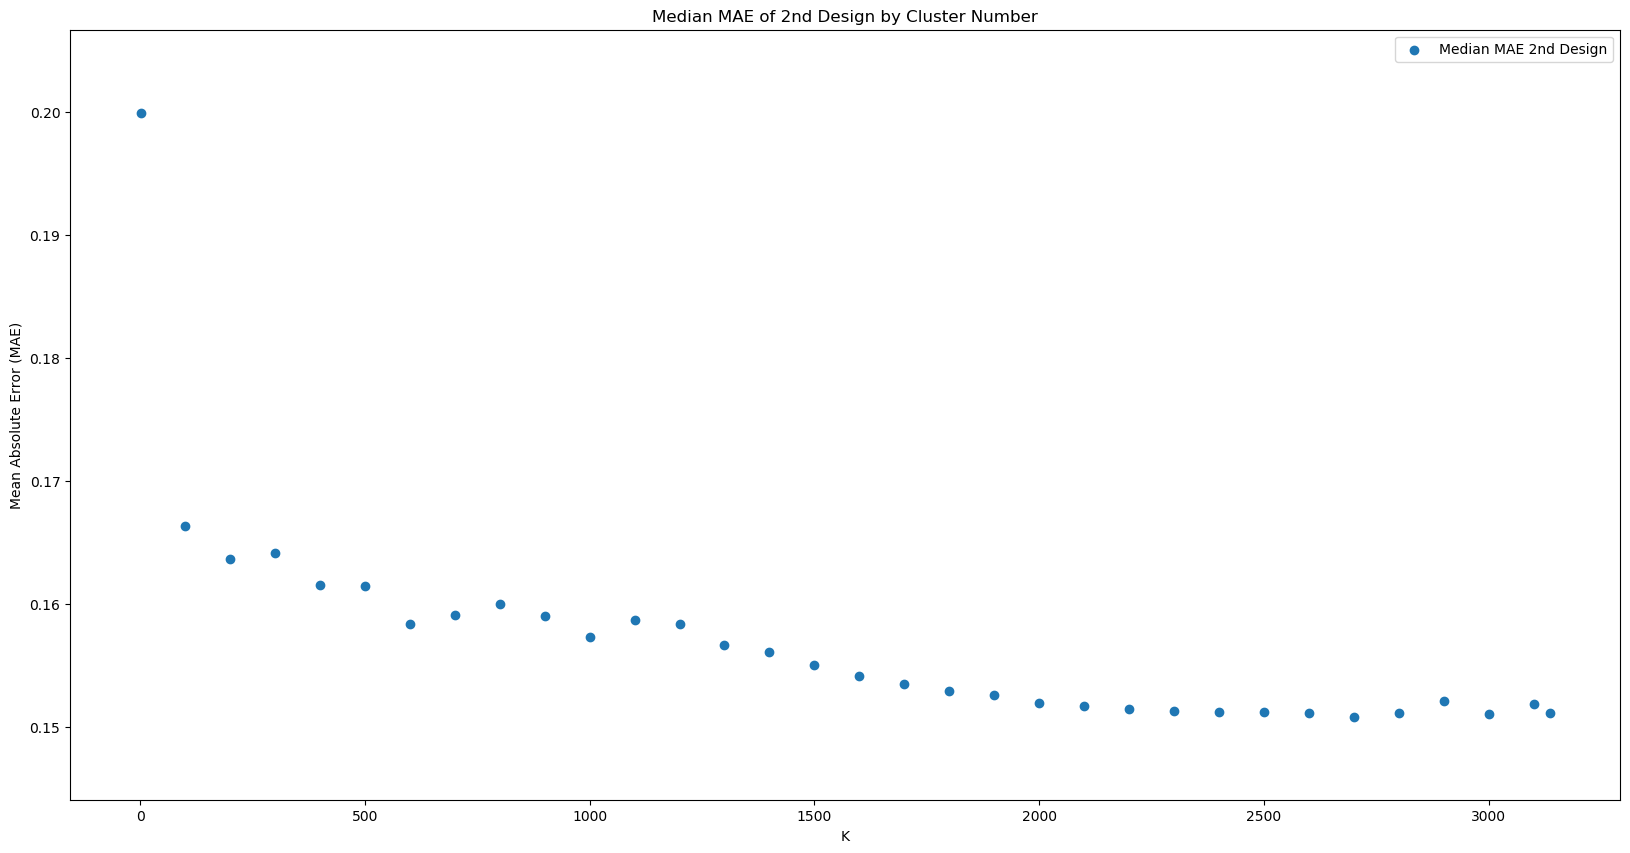

In [22]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(median_df["K"], median_df["Median MAE"], label="Median MAE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median MAE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Mean Absolute Error (MAE)')

plt.show()

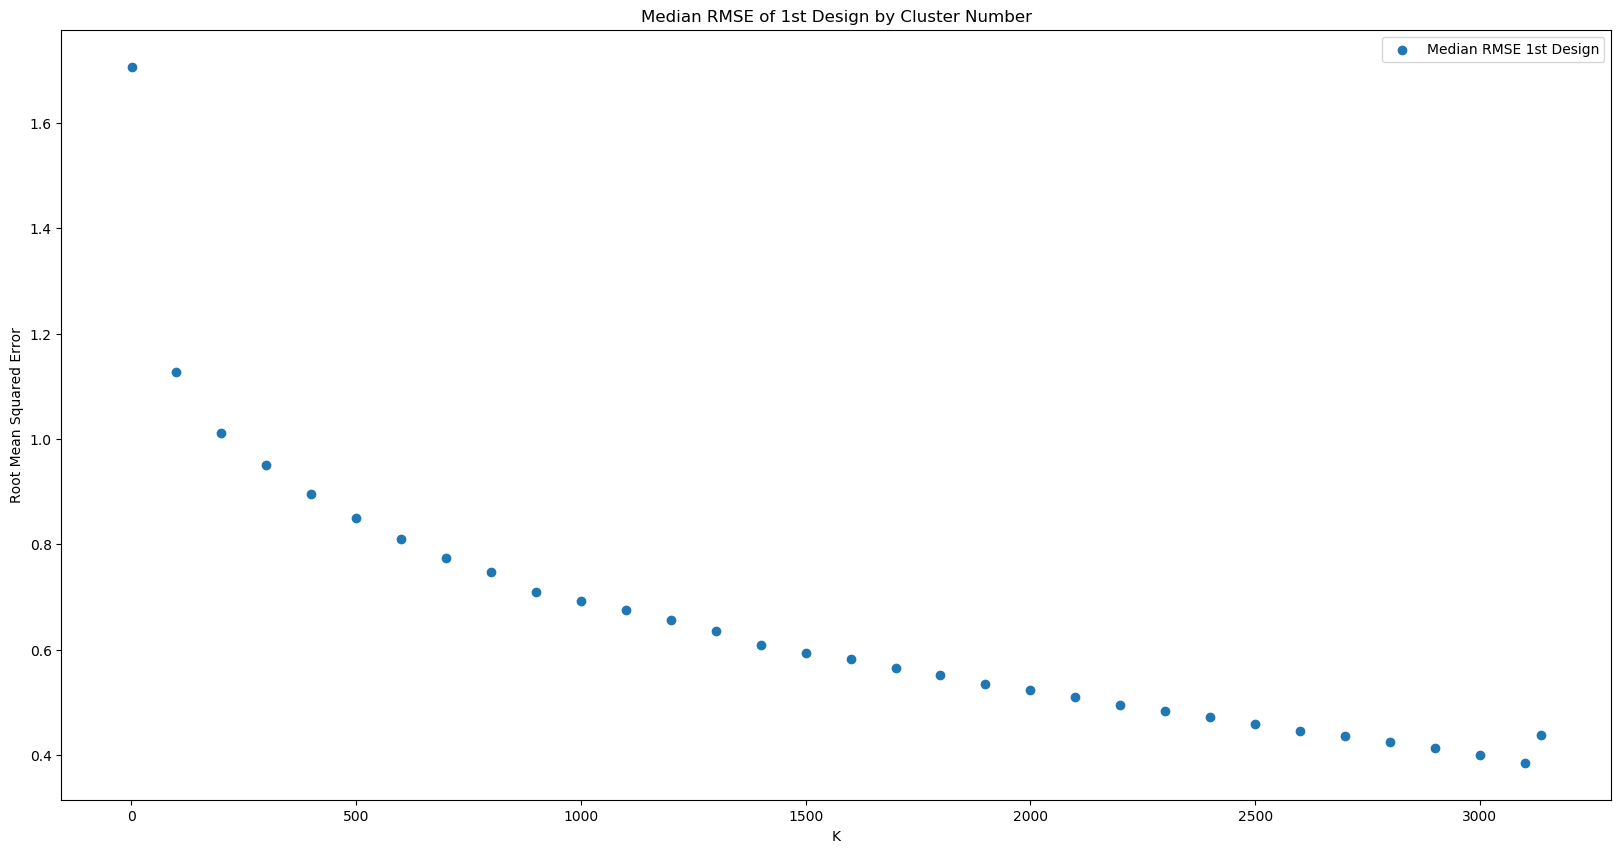

In [23]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(first_median_df["K"], first_median_df["Median RMSE"], label="Median RMSE 1st Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE of 1st Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Root Mean Squared Error')

plt.show()

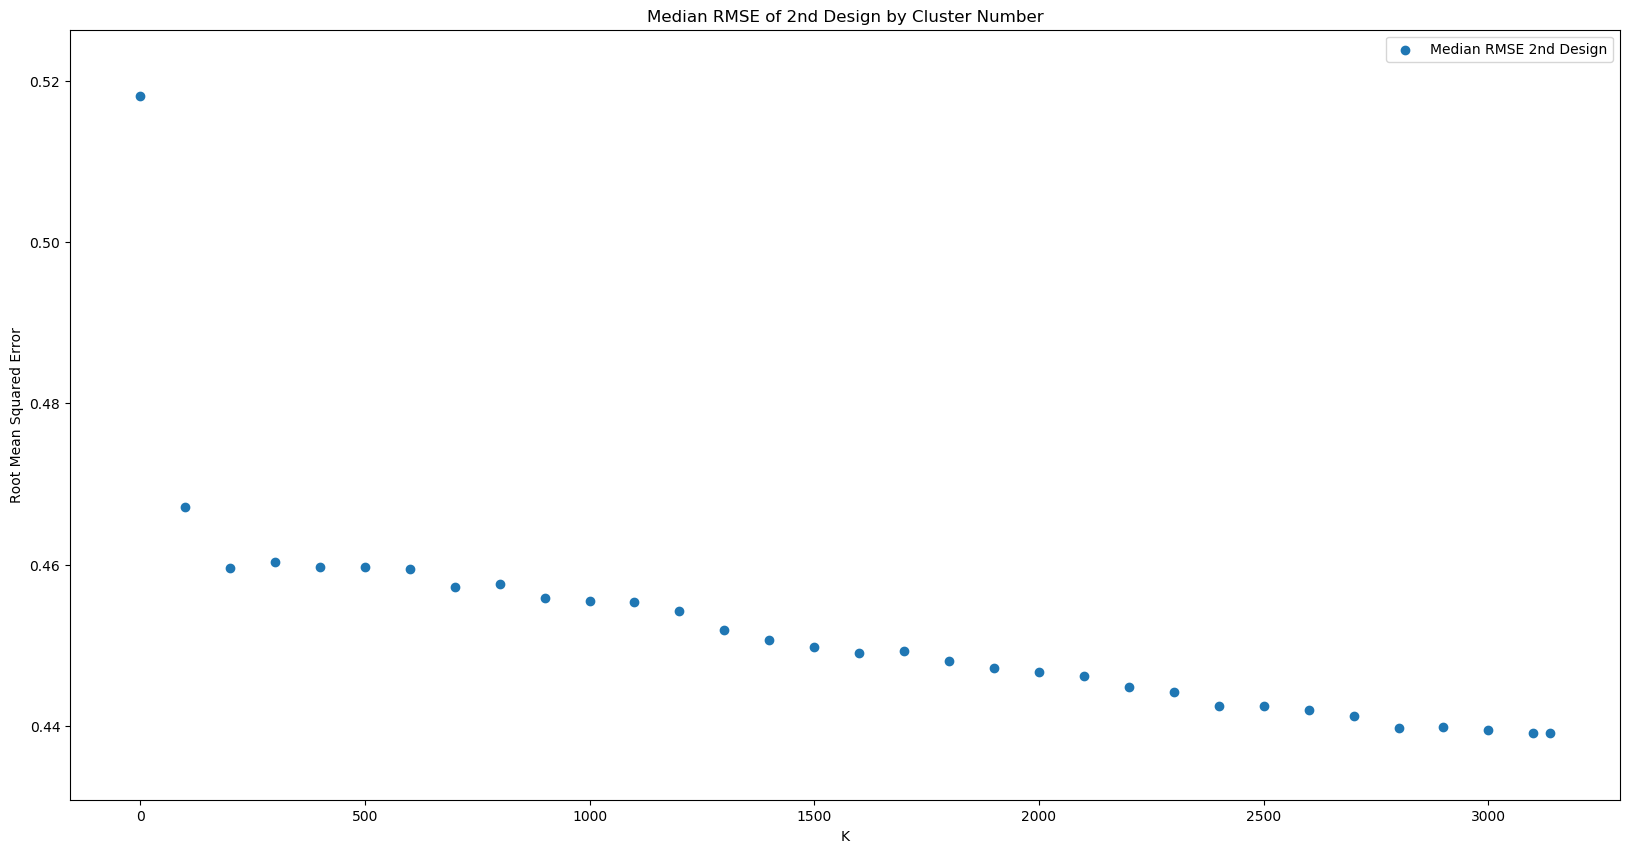

In [24]:
figsize=(20,10)
plt.subplots(figsize=figsize)

plt.scatter(median_df["K"], median_df["Median RMSE"], label="Median RMSE 2nd Design")
# Add a legend to the first subplot
plt.legend()
plt.title('Median RMSE of 2nd Design by Cluster Number')
plt.xlabel('K')
plt.ylabel('Root Mean Squared Error')

plt.show()